DNN Models under DIA
- Deep2S: Hybrid model (adjoint operator + 3D U-Net)
- CV-Deep2S: Hybrid model with fully complex-valued operations
- Deep2SP+: Pure DNN-based model

- Imports

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
from scipy.ndimage import label, binary_dilation
from src import src, misc 

print(tf.config.list_physical_devices('GPU')) 

- Victim Imaging/Forward imaging: Load select pre-trained DNN model (out of 3) 

In [ ]:
#--------------------------- victim forward imaging 
def get_model_pipeline(model_name):
    """Returns the DNN and its specific forward operator logic."""
    if model_name == 'Deep2S':
        dnn = src.get_UNet3D(input_shape=(X, Y, Z, 1))
        dnn.load_weights("models_weights/experimental/Deep2S/model_Nf15_SNR30_exp.h5")
        
        def forward(y_batch, A_conj): # magnitude output
            AHy = tf.einsum('ktrxyz,Nktr->Nxyz', A_conj, y_batch)
            mag = tf.abs(AHy)
            max_mag = tf.reduce_max(mag, axis=(1,2,3), keepdims=True)
            mag_norm = mag / (max_mag + 1e-12) # [0,1]
            return dnn(mag_norm[..., None], training=False)

    elif model_name == 'CV-Deep2S': # complex value output
        dnn = src.get_CV_UNet(input_shape=(X, Y, Z, 2))
        dnn.load_weights("models_weights/experimental/CV-Deep2S/model_Nf15_SNR30_CV_exp.h5")
        
        def forward(y_batch, A_conj):
            AHy = tf.einsum('ktrxyz,Nktr->Nxyz', A_conj, y_batch)
            max_mag = tf.reduce_max(tf.abs(AHy), axis=(1,2,3), keepdims=True)
            AHy_norm = AHy / tf.cast(max_mag + 1e-12, tf.complex64)
            AHy_ri = tf.stack([tf.math.real(AHy_norm), tf.math.imag(AHy_norm)], axis=-1)
            return dnn(AHy_ri, training=False)

    elif model_name == 'Deep2SP+':
        # End-to-end model (complex input)
        dnn = tf.keras.models.load_model("models_weights/experimental/Deep2S-Plus/model_Nf15_SNR30_Deep2SP_exp", compile=False)
        
        def forward(y_batch, A_conj=None):

            #----------- added norm, not in the orginal code
            y_ri = tf.stack([tf.math.real(y_batch), tf.math.imag(y_batch)], axis=-1)
            return dnn(y_ri, training=False)
            #max_mag = tf.reduce_max(tf.abs(y_batch), axis=(1,2,3), keepdims=True)  # (N,1,1,1)
            #y_norm = y_batch / tf.cast(max_mag + 1e-12, tf.complex64)

            #y_ri = tf.stack([tf.math.real(y_norm), tf.math.imag(y_norm)], axis=-1)  # (N,K,T,R,2)
            #return dnn(y_ri, training=False)              
    return dnn, forward


#--------------------------- generate target image
import numpy as np
import tensorflow as tf
from scipy.ndimage import label, binary_dilation


def generate_target_img(
    clean_img,
    victim_forward,
    sarRawData,   # (1,K,T,R) complex64
    A_conj_tf,
    attack_mode=None,
    seed=42,
):
    # ---- clean (for ROI mask only)
    c = clean_img[..., 0] if len(clean_img.shape) == 5 else clean_img   # (1,X,Y,Z)

    # ---- shuffle raw measurements across aperture (per fast-time k)
    y = sarRawData[0].numpy()                                           # (K,T,R) complex64
    K, T, R = y.shape
    Np = T * R

    Xv = y.reshape(K, Np)                                               # (K,TR)
    rng = np.random.default_rng(seed)
    for k in range(K):
        Xv[k, :] = Xv[k, rng.permutation(Np)]

    y_shuf = tf.constant(
        Xv.reshape(K, T, R)[None, ...],
        dtype=tf.complex64
    )                                                                    # (1,K,T,R)

    # ---- target = victim_forward(shuffled measurements)
    target_img = victim_forward(y_shuf, A_conj_tf)                       # (1,X,Y,Z,1) or (1,X,Y,Z)
    t = target_img[..., 0] if len(target_img.shape) == 5 else target_img # (1,X,Y,Z)

    # ---- ROI mask (same logic as before, based on CLEAN image)
    roi_mask = None
    if attack_mode == "ROI":
        c_np = c.numpy()[0]                                              # (X,Y,Z)
        clean_mip = c_np.max(axis=2)                                     # (X,Y)

        thresh = 0.7 * clean_mip.max()
        binary = clean_mip > thresh

        labels, num_features = label(binary)
        if num_features > 0:
            largest_label = np.argmax(np.bincount(labels.ravel())[1:]) + 1
            roi_2d = binary_dilation(labels == largest_label, iterations=1)

            Z = c_np.shape[2]
            roi_3d = np.repeat(roi_2d[..., None], Z, axis=2)
            roi_mask = tf.constant(roi_3d, dtype=tf.float32)

    return t, roi_mask

'\n# Model-agnostic min-max normalization to [0,1]\ndef minmax01_norm(img, eps=1e-12):\n   s """\n    Min-max normalize to [0,1].\n    Preserves ordering (contrast), not absolute physical scale.\n    """\n    if len(img.shape) == 5:\n        img = img[..., 0]  # remove channel -> (N,X,Y,Z)\n\n    x_min = tf.reduce_min(img)\n    x_max = tf.reduce_max(img)\n    return (img - x_min) / (x_max - x_min + eps)\n\n\ndef maxabs_norm(img, eps=1e-12):\n    """\n    Normalize by global max-abs so output is in [-1,1] (or [0,1] if input is nonnegative).\n    """\n    if len(img.shape) == 5:\n        img = img[..., 0]  # (N,X,Y,Z)\n\n    denom = tf.reduce_max(tf.abs(img))\n    return img / (denom + eps)\n'

- Testing only: dimension analysis

clean_img: (1, 25, 25, 49, 1) <dtype: 'float32'>
target_img: (1, 25, 25, 49) <dtype: 'float32'>
roi_mask : None
clean_img: (1, 25, 25, 49, 1) <dtype: 'float32'>
target_img: (1, 25, 25, 49) float32
clean min/max: 0.00031718536047264934 0.9893040657043457
target min/max: 0.0006156152812764049 0.6380876898765564
c_np: (25, 25, 49) float32
t_np: (25, 25, 49) float32


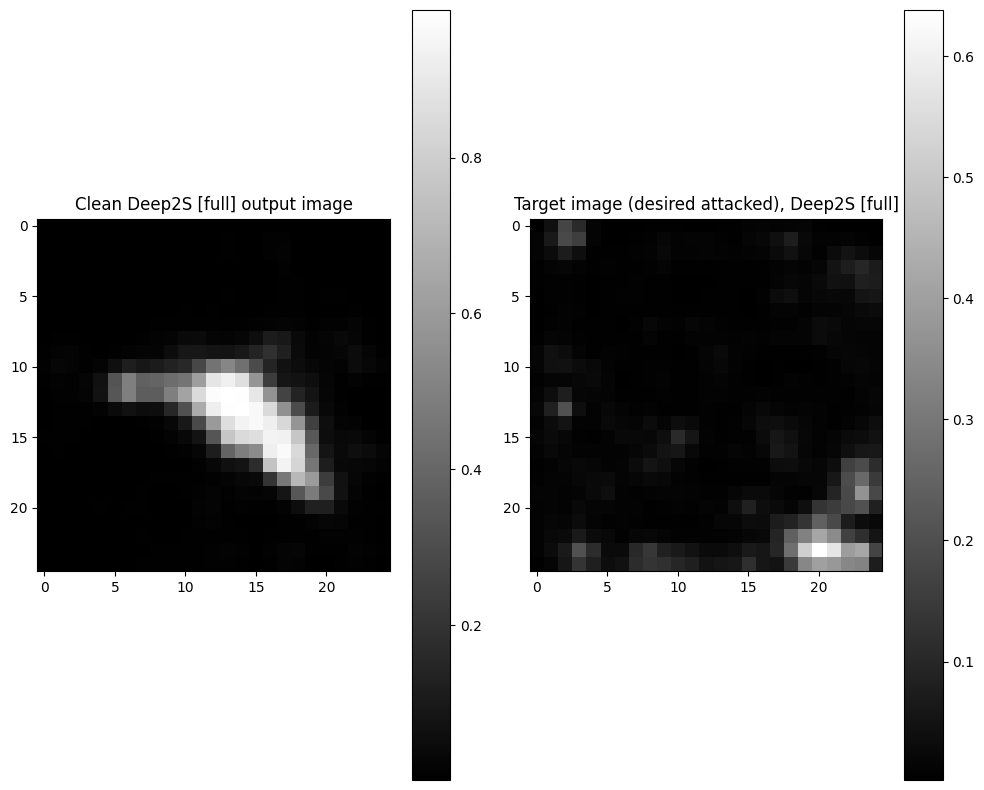

In [146]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# ------------------ config
MODEL_TYPE  = "Deep2S"   # 'Deep2S', 'CV-Deep2S', 'Deep2SP+'
ATTACK_MODE = "full"       # 'Full' or 'ROI'
tf.random.set_seed(0)
np.random.seed(0)

# ------------------ load models/data
A = np.load("models_weights/experimental/A15_exp.npy")
K, T, R, X, Y, Z = A.shape
A_conj_tf = tf.math.conj(tf.constant(A.astype(np.complex64)))

sarRawData_temp = np.load("data/y_exp_test_4.npy").astype(np.complex64)   # (K,T,R)
sarRawData = tf.constant(sarRawData_temp[None, ...])                     # (1,K,T,R)

D   = tf.constant(np.load("data/D_flat.npy").astype(np.complex64))
X_v = tf.constant(sarRawData_temp.reshape(K, T * R))

dnn_model, victim_forward = get_model_pipeline(MODEL_TYPE)

# ------------------ clean iamge + target image
clean_img = victim_forward(sarRawData, A_conj_tf)                        # e.g., (1,X,Y,Z,1) or (1,X,Y,Z)
# target image from shuffled measurements
target_img, roi_mask = generate_target_img(
    clean_img=clean_img,
    victim_forward=victim_forward,
    sarRawData=sarRawData,
    A_conj_tf=A_conj_tf,
    attack_mode=ATTACK_MODE,   # "Full" or "ROI"
    seed=42
)

print("clean_img:", clean_img.shape, clean_img.dtype)
print("target_img:", target_img.shape, target_img.dtype)   # TF tensor now
print("roi_mask :", None if roi_mask is None else roi_mask.shape)

print("clean_img:", clean_img.shape, clean_img.dtype)
print("target_img:", np.asarray(target_img).shape, np.asarray(target_img).dtype)

# clean_img min/max (TF)
print("clean min/max:",
      tf.reduce_min(clean_img).numpy().item(),
      tf.reduce_max(clean_img).numpy().item())

# target_img min/max (NumPy)
t = np.asarray(target_img)
print("target min/max:", float(t.min()), float(t.max()))
# ------------------ PLOT CLEAN + TARGET (MIP)  [no vmin/vmax]

# ---- drop channel if needed: (1,X,Y,Z,1) -> (1,X,Y,Z)
c_vol = clean_img[..., 0] if len(clean_img.shape) == 5 else clean_img
t_vol = target_img[..., 0] if (tf.is_tensor(target_img) and len(target_img.shape) == 5) else target_img

# ---- to numpy volumes: (X,Y,Z)
c_np = c_vol.numpy()[0]
t_np = t_vol.numpy()[0] if tf.is_tensor(t_vol) and len(t_vol.shape) == 4 else np.asarray(t_vol)

print("c_np:", c_np.shape, c_np.dtype)
print("t_np:", t_np.shape, t_np.dtype)

# ---- MIP along Z: (X,Y)
clean_mip  = c_np.max(axis=2)
target_mip = t_np.max(axis=2)

plt.figure(figsize=(10, 8))

plt.subplot(1, 2, 1)
plt.imshow(clean_mip, origin="upper", cmap="gray")
plt.title(f"Clean {MODEL_TYPE} [{ATTACK_MODE}] output image")
plt.colorbar()

plt.subplot(1, 2, 2)
plt.imshow(target_mip, origin="upper", cmap="gray")
plt.title(f"Target image (desired attacked), {MODEL_TYPE} [{ATTACK_MODE}]")
plt.colorbar()

plt.tight_layout()
plt.show()

DIA optimization

In [157]:
# ------------------ config
MODEL_TYPE  = "Deep2SP+"   # 'Deep2S', 'CV-Deep2S', 'Deep2SP+'
ATTACK_MODE = "ROI"       # 'Full' or 'ROI'
tf.random.set_seed(0)
np.random.seed(0)

# ---- Attack hyperparameters (moved here) ----
CONFIG_MAP = {
    'Deep2S': {
        'Full': {'Amax': 2.0, 'lambda_L2': 1e-5, 'max_iter': 1000, 'lr_init': 1e-1,  'lr_switch_iter': 10000, 'low_lr': 1e-2}, 
        'ROI':  {'Amax': 2.0, 'lambda_L2': 1e-5, 'max_iter': 1000, 'lr_init': 1e-1, 'lr_switch_iter': 10000, 'low_lr': 1e-2},
    },
    'CV-Deep2S': {
        'Full': {'Amax': 2.0, 'lambda_L2': 1e-5, 'max_iter': 1000, 'lr_init': 1e0,  'lr_switch_iter': 100000, 'low_lr': 1e-2},
        'ROI':  {'Amax': 2.0, 'lambda_L2': 1e-5, 'max_iter': 1000, 'lr_init': 1e1,  'lr_switch_iter': 100000, 'low_lr': 1e-2},
    },
    'Deep2SP+': {
        'Full': {'Amax': 2.0, 'lambda_L2': 1e-5, 'max_iter': 1000, 'lr_init': 1e-1, 'lr_switch_iter': 100000, 'low_lr': 1e-2},
        'ROI':  {'Amax': 2.0, 'lambda_L2': 1e-5, 'max_iter': 1000, 'lr_init': 1e1, 'lr_switch_iter': 100000, 'low_lr': 1e-2},
    }
}

# ------------------ load models/data
A = np.load("models_weights/experimental/A15_exp.npy")
K, T, R, X, Y, Z = A.shape
A_conj_tf = tf.math.conj(tf.constant(A.astype(np.complex64)))

sarRawData_temp = np.load("data/y_exp_test_4.npy").astype(np.complex64)   # (K,T,R)
sarRawData = tf.constant(sarRawData_temp[None, ...])                     # (1,K,T,R)

D   = tf.constant(np.load("data/D_flat.npy").astype(np.complex64))
X_v = tf.constant(sarRawData_temp.reshape(K, T * R))

dnn_model, victim_forward = get_model_pipeline(MODEL_TYPE)

# ------------------ forward + target
clean_img = victim_forward(sarRawData, A_conj_tf)                     
c = clean_img[..., 0] if len(clean_img.shape) == 5 else clean_img
global_scale = tf.reduce_max(tf.abs(c)) + 1e-12

clean_img = clean_img/global_scale

target_img, roi_mask = generate_target_img(
    clean_img=clean_img,
    victim_forward=victim_forward,
    sarRawData=sarRawData,
    A_conj_tf=A_conj_tf,
    attack_mode=ATTACK_MODE,   # "Full" or "ROI"
    seed=42
)

# ---- make target shape match adv_img shape
if len(clean_img.shape) == 5 and len(target_img.shape) == 4:
    target_img = target_img[..., None]   # (1,X,Y,Z) -> (1,X,Y,Z,1)

target_img = target_img/global_scale

#------------------- normalize clean and target, target image is numpy that is why we did not use minmax01_norm()
#clean_img = maxabs_norm(clean_img)
#target_img = target_img / (target_img.max() + 1e-12) 

# ------------------ hypterparameters
params = dict(CONFIG_MAP[MODEL_TYPE][ATTACK_MODE])
Amax           = params['Amax']
lambda_L2      = params['lambda_L2']
max_iter       = params['max_iter']
lr_init        = params['lr_init'] # intial learning rate
lr_switch_iter = params['lr_switch_iter']
low_lr         = params['low_lr']

A_re = tf.Variable(1e-3 * tf.random.normal(shape=(T*R,)))
A_im = tf.Variable(1e-3 * tf.random.normal(shape=(T*R,)))

optimizer = tf.keras.optimizers.Adam(learning_rate=lr_init)

@tf.function
def train_step(A_re, A_im, opt_lr):
    optimizer.learning_rate.assign(opt_lr)

    with tf.GradientTape() as tape:        
        A_complex = tf.complex(A_re, A_im)

        A_row = tf.reshape(A_complex, (1, T * R))                 # (1, TR)
        delta = D * A_row                               # same shape as X_v
        Y_att = tf.reshape(X_v + delta, (1, K, T, R))

        # ---- victim forward + norm ----
        adv_img = victim_forward(Y_att, A_conj_tf)
        adv_img =adv_img/global_scale

        # ---- MSE(A,T): attacked vs target ----
        if ATTACK_MODE == 'ROI':
            diff_AT = tf.boolean_mask(adv_img[0] - target_img[0], roi_mask)
            mse_AT = tf.reduce_mean(diff_AT**2)
        else:
            mse_AT = tf.reduce_mean((adv_img - target_img)**2)

        # ---- regularizer on A ----
        loss_reg = lambda_L2 * tf.reduce_mean(tf.abs(A_complex)**2)
        total_loss = mse_AT + loss_reg

    # ---- grads + step ----
    grads = tape.gradient(total_loss, [A_re, A_im])
    optimizer.apply_gradients(zip(grads, [A_re, A_im]))
    
    A_complex = tf.complex(A_re, A_im)
    A_mag = tf.abs(A_complex)

    # =====================================================
    # HARD MAGNITUDE PROJECTION  |A_i| <= Amax   (CRITICAL)
    # =====================================================
    scale = tf.minimum(1.0, Amax / (A_mag + 1e-12))
    A_proj = A_complex * tf.cast(scale, tf.complex64)

    A_re.assign(tf.math.real(A_proj))
    A_im.assign(tf.math.imag(A_proj))

    # ---- metrics that don't affect gradients ----
    gmax = tf.maximum(tf.reduce_max(tf.abs(grads[0])), tf.reduce_max(tf.abs(grads[1])))
    meanA = tf.reduce_mean(tf.abs(A_proj))
    maxA  = tf.reduce_max(tf.abs(A_proj))

    # MSE(C,A): clean vs attacked (use same ROI/full choice for apples-to-apples)
    if ATTACK_MODE == 'ROI':
        diff_CA = tf.boolean_mask(adv_img[0] - clean_img[0], roi_mask)
        mse_CA = tf.reduce_mean(diff_CA**2)
    else:
        mse_CA = tf.reduce_mean((adv_img - clean_img)**2)

    # Pa/Pr ≈ (||delta|| / ||clean||)^2
    #PaPr = tf.math.square(tf.linalg.norm(delta) / (tf.linalg.norm(X_v) + 1e-12))
    PaPr = tf.square(tf.linalg.norm(tf.abs(delta)) / (tf.linalg.norm(tf.abs(X_v)) + 1e-12))

    return total_loss, gmax, mse_AT, mse_CA, meanA, maxA, PaPr

print(f"Starting {ATTACK_MODE} attack on {MODEL_TYPE} lr_init={lr_init:.2e}")
for it in range(1, max_iter + 1):
    current_lr = lr_init if it <= lr_switch_iter else low_lr

    loss_val, gmax, mse_AT, mse_CA, meanA, maxA, PaPr = train_step(A_re, A_im, current_lr)

    if it % 50 == 0 or it == 1 or it == max_iter:

        print(
            f"Iter {it:04d}/{max_iter:04d}| "
            f"Loss={loss_val.numpy().item():.4e}, G={gmax.numpy().item():.6e} | "
            f"MSE(A,T)={mse_AT.numpy().item():.4e}, MSE(C,A)={mse_CA.numpy().item():.4e} | "
            f"E|A|={meanA.numpy().item():.4e}, max|A|={maxA.numpy().item():.4e}, Pa/Pr={PaPr.numpy().item():.4e}"
        )

print("Attack optimization finished.")

Starting ROI attack on Deep2SP+ lr_init=1.00e+01
Iter 0001/1000| Loss=9.2317e-02, G=4.652337e-03 | MSE(A,T)=9.2317e-02, MSE(C,A)=6.2531e-08 | E|A|=2.0000e+00, max|A|=2.0000e+00, Pa/Pr=2.1472e-06
Iter 0050/1000| Loss=5.3770e-05, G=4.972318e-07 | MSE(A,T)=1.4326e-05, MSE(C,A)=9.2485e-02 | E|A|=1.9815e+00, max|A|=2.0000e+00, Pa/Pr=3.9804e+00
Iter 0100/1000| Loss=2.9824e-05, G=4.274868e-07 | MSE(A,T)=1.2235e-05, MSE(C,A)=9.2388e-02 | E|A|=1.2219e+00, max|A|=2.0000e+00, Pa/Pr=2.3161e+00
Iter 0150/1000| Loss=2.1022e-05, G=2.515019e-07 | MSE(A,T)=1.1031e-05, MSE(C,A)=9.2284e-02 | E|A|=8.6151e-01, max|A|=2.0000e+00, Pa/Pr=1.5535e+00
Iter 0200/1000| Loss=1.7785e-05, G=2.612966e-07 | MSE(A,T)=9.7496e-06, MSE(C,A)=9.2254e-02 | E|A|=7.5498e-01, max|A|=2.0000e+00, Pa/Pr=1.3516e+00
Iter 0250/1000| Loss=1.6549e-05, G=2.005750e-07 | MSE(A,T)=9.1833e-06, MSE(C,A)=9.2212e-02 | E|A|=7.1103e-01, max|A|=2.0000e+00, Pa/Pr=1.2750e+00
Iter 0300/1000| Loss=1.6107e-05, G=2.082392e-07 | MSE(A,T)=8.8713e-06, MSE(

Attacked reconstruction and visualization


--- Physics-based attack metrics (MIP-level, NO normalization) ---
MSE(A,T)   : 7.3279e-04  (matlab equiv: 7.5643e-01)
MSE(C,A)   : 4.4489e-02
NCC        : 0.6218
SSIM (full): 0.4990
PSNR (full): 20.69 dB

--- ROI-only metrics (computed on ROI pixels only) ---
MSE(A,T)_ROI : 4.3180e-05
SSIM_ROI     : 0.8206
PSNR_ROI     : 14.86 dB


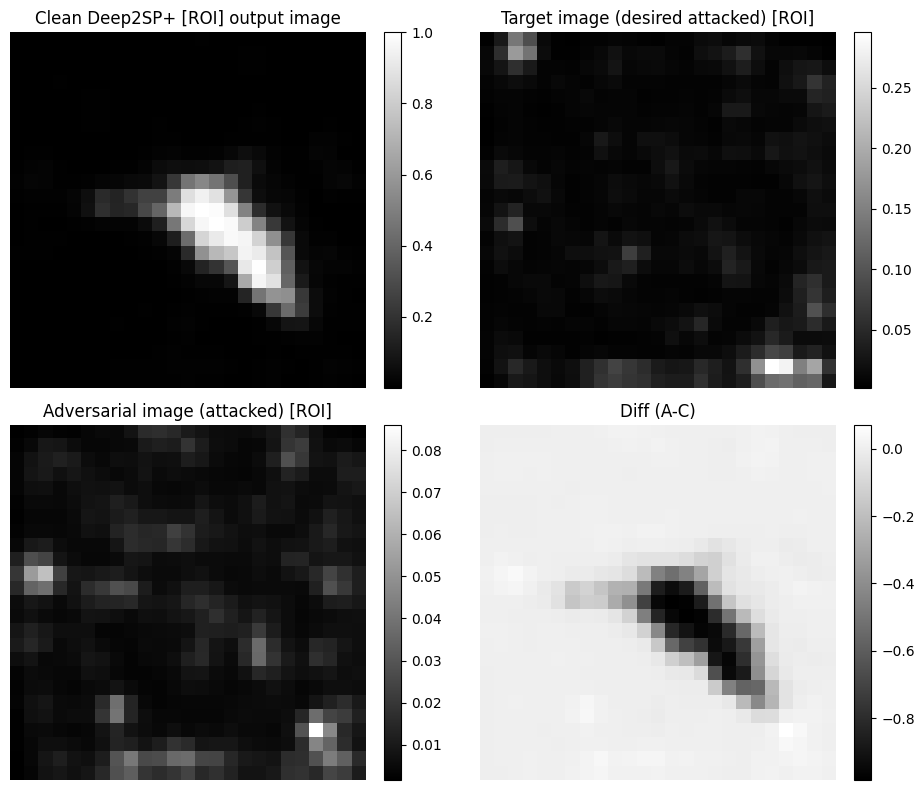

In [159]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

EPS = 1e-12

# ------------------ final attacked measurement + reconstruction (NO normalization)
A_opt_tf  = tf.complex(A_re, A_im)                           # (TR,)
A_opt_row = tf.reshape(A_opt_tf, (1, T * R))                 # (1,TR)
Y_opt_tf  = tf.reshape(X_v + D * A_opt_row, (1, K, T, R))    # (1,K,T,R)

attacked_vol = victim_forward(Y_opt_tf, A_conj_tf)           # TF
attacked_vol = attacked_vol / global_scale                   # keep your scaling
clean_vol    = clean_img                                     # TF
target_vol   = target_img                                    # TF or NP

# ------------------ drop channel if needed -> aim for (1,X,Y,Z)
att4 = attacked_vol[..., 0] if len(attacked_vol.shape) == 5 else attacked_vol
cln4 = clean_vol[..., 0]    if len(clean_vol.shape)    == 5 else clean_vol

# target: TF or NP, may be (1,X,Y,Z,1) or (1,X,Y,Z) or (X,Y,Z)
if tf.is_tensor(target_vol):
    tgt4  = target_vol[..., 0] if len(target_vol.shape) == 5 else target_vol
    tgt_np = tgt4.numpy()
else:
    tgt_np = np.asarray(target_vol)

if tgt_np.ndim == 4:        # (1,X,Y,Z)
    tgt3 = tgt_np[0]
elif tgt_np.ndim == 3:      # (X,Y,Z)
    tgt3 = tgt_np
else:
    raise ValueError(f"Unexpected target_vol shape: {tgt_np.shape}")

# ------------------ MIP to 2D (X,Y)
adv = tf.reduce_max(att4[0], axis=2).numpy().astype(np.float32)   # (X,Y)
cln = tf.reduce_max(cln4[0], axis=2).numpy().astype(np.float32)   # (X,Y)
tgt = np.max(tgt3, axis=2).astype(np.float32)                    # (X,Y)

# ------------------ FULL-image metrics (as you already had)
mse_AT = np.mean((adv - tgt) ** 2)
mse_CA = np.mean((adv - cln) ** 2)

adv_rms = adv / (np.sqrt(np.mean(adv**2)) + EPS)
tgt_rms = tgt / (np.sqrt(np.mean(tgt**2)) + EPS)
mse_AT2 = np.mean((adv_rms - tgt_rms) ** 2)

num = np.sum(adv * tgt)
den = np.sqrt(np.sum(adv**2) * np.sum(tgt**2)) + EPS
ncc_val = num / den

data_range = float(tgt.max() - tgt.min() + EPS)
ssim_val_full = ssim(adv, tgt, data_range=data_range)
psnr_val_full = psnr(tgt, adv, data_range=data_range)

# ------------------ ROI-only PSNR/SSIM (ONLY if ATTACK_MODE == "ROI")
psnr_val_roi = None
ssim_val_roi = None
mse_AT_roi   = None

if ATTACK_MODE == "ROI":
    if roi_mask is None:
        raise ValueError("ATTACK_MODE='ROI' but roi_mask is None")

    # roi_mask is 3D (X,Y,Z) float32 TF in your generator
    roi3 = roi_mask.numpy().astype(bool)          # (X,Y,Z)
    roi2 = np.any(roi3, axis=2)                   # (X,Y) -> MIP-consistent ROI support

    adv_roi = adv[roi2]
    tgt_roi = tgt[roi2]

    mse_AT_roi = np.mean((adv_roi - tgt_roi) ** 2)

    dr_roi = float(tgt_roi.max() - tgt_roi.min() + EPS)
    psnr_val_roi = psnr(tgt_roi, adv_roi, data_range=dr_roi)

    # SSIM needs 2D arrays; compute SSIM on cropped ROI bounding box (standard trick)
    ys, xs = np.where(roi2)
    y0, y1 = ys.min(), ys.max() + 1
    x0, x1 = xs.min(), xs.max() + 1

    adv_crop = adv[y0:y1, x0:x1]
    tgt_crop = tgt[y0:y1, x0:x1]
    roi_crop = roi2[y0:y1, x0:x1]

    # mask outside ROI in the crop to avoid penalizing outside pixels
    # (keeps array 2D so skimage.ssim works)
    adv_crop_m = adv_crop.copy()
    tgt_crop_m = tgt_crop.copy()
    adv_crop_m[~roi_crop] = 0.0
    tgt_crop_m[~roi_crop] = 0.0

    dr_crop = float(tgt_crop_m.max() - tgt_crop_m.min() + EPS)
    ssim_val_roi = ssim(adv_crop_m, tgt_crop_m, data_range=dr_crop)

print("\n--- Physics-based attack metrics (MIP-level, NO normalization) ---")
print(f"MSE(A,T)   : {mse_AT:.4e}  (matlab equiv: {mse_AT2:.4e})")
print(f"MSE(C,A)   : {mse_CA:.4e}")
print(f"NCC        : {ncc_val:.4f}")
print(f"SSIM (full): {ssim_val_full:.4f}")
print(f"PSNR (full): {psnr_val_full:.2f} dB")

if ATTACK_MODE == "ROI":
    print("\n--- ROI-only metrics (computed on ROI pixels only) ---")
    print(f"MSE(A,T)_ROI : {mse_AT_roi:.4e}")
    print(f"SSIM_ROI     : {ssim_val_roi:.4f}")
    print(f"PSNR_ROI     : {psnr_val_roi:.2f} dB")

# ------------------ plot (NO vmin/vmax, WITH colorbars)
plt.figure(figsize=(10, 8))

ax1 = plt.subplot(2,2,1)
im1 = ax1.imshow(cln, cmap="gray")
ax1.set_title(f"Clean {MODEL_TYPE} [{ATTACK_MODE}] output image")
ax1.axis("off")
plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

ax2 = plt.subplot(2,2,2)
im2 = ax2.imshow(tgt, cmap="gray")
ax2.set_title(f"Target image (desired attacked) [{ATTACK_MODE}]")
ax2.axis("off")
plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

ax3 = plt.subplot(2,2,3)
im3 = ax3.imshow(adv, cmap="gray")
ax3.set_title(f"Adversarial image (attacked) [{ATTACK_MODE}]")
ax3.axis("off")
plt.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)

ax4 = plt.subplot(2,2,4)
im4 = ax4.imshow(adv - cln, cmap="gray")
ax4.set_title("Diff (A-C)")
ax4.axis("off")
plt.colorbar(im4, ax=ax4, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()
